# Graphics and Visuals on Background Information 
## EEP 153 — Project 3

**Zeynep Ganley** 

**Data Source:** [Tanzania - Hicks Google Sheet](https://docs.google.com/spreadsheets/d/1LRe2bjhimuwrTXU8MpmQFH02MJegNRpmwNkY9T3HGqA/edit)

---

In [3]:
# Install required packages
#!pip install -r requirements.txt

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# **Rural and Urban Distribution of Populations Across Tanzania**

In [10]:
DATA_PATH_1 = "rural_urban.csv"
geo_pop = pd.read_csv(DATA_PATH_1, skiprows=1, header=None)
col_names = ["Measurement", "Value"]
geo_pop.columns = col_names
geo_pop.head()

,Measurement,Value
0,total population,61741120
1,urban population,21544623
2,rural population,40196497
3,male population,30053130
4,female population,31687990


In [23]:
wanted = ["male urban population", "female urban population", "male rural population", "female rural population"]

geo_pop_filtered = geo_pop[geo_pop["Measurement"].isin(wanted)]

geo_pop_plot = geo_pop_filtered.set_index("Measurement")["Value"].to_frame().T
print(geo_pop_plot)

Measurement  male urban population  female urban population  \
Value                     10333679                 11210944   

Measurement  male rural population  female rural population  
Value                     19719451                 20477046  


In [35]:
wanted_1 = ["total population "]

pop_total_filtered = geo_pop[geo_pop["Measurement"].isin(wanted_1)]

pop_total_plot = pop_total_filtered.set_index("Measurement")["Value"].to_frame().T

pop_total_plot = pop_total_filtered["Value"].iloc[0]
print(pop_total_plot, type(pop_total_plot))

61741120 <class 'numpy.int64'>


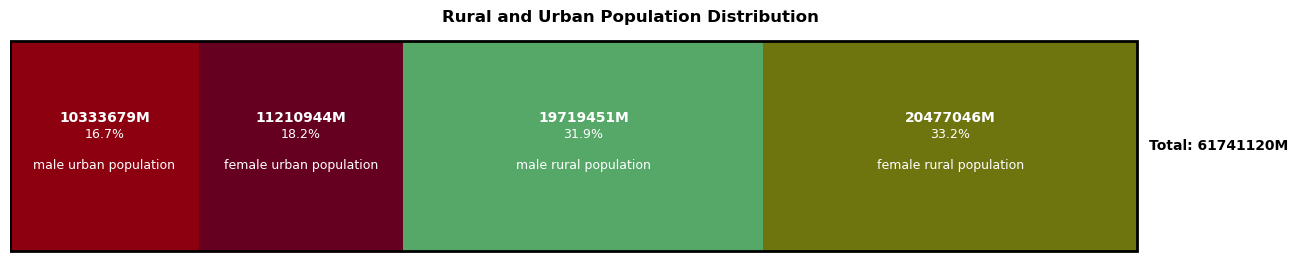

In [52]:
import matplotlib.pyplot as plt

# Example filtered data
demographic = geo_pop_filtered["Measurement"].tolist()  
population = geo_pop_filtered["Value"].tolist()         
colors = ["#8C000F", "#650021", "#55A868", "#6E750E"]

# Compute total population
pop_total_plot = sum(population)

plt.figure(figsize=(16, 3))
left = 0

for i, width in enumerate(population):
    # Draw segment
    plt.barh(y=0, width=width, left=left, color=colors[i])
    
    # Compute percentage
    pct = width / pop_total_plot * 100
    
    
    text_color = "white" if width/pop_total_plot > 0.08 else "black"
    
    # Population number
    plt.text(
        x=left + width/2,
        y=0.08,
        s=f"{population[i]}M",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color=text_color
    )
    
    # Percentage
    plt.text(
        x=left + width/2,
        y=0.02,
        s=f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9,
        color=text_color
    )
    
    # Demographic name
    plt.text(
        x=left + width/2,
        y=-0.05,
        s=demographic[i],
        ha="center",
        va="top",
        fontsize=9,
        color=text_color
    )
    
    left += width

# Outer rectangle for total
plt.barh(y=0, width=pop_total_plot, left=0, fill=False, edgecolor="black", linewidth=2)

# Total population label outside
plt.text(
    x=pop_total_plot + pop_total_plot*0.01,
    y=0,
    s=f"Total: {pop_total_plot}M",
    va="center",
    ha="left",
    fontsize=10,
    fontweight="bold"
)

# styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

plt.xticks([])
plt.yticks([])
plt.xlim(0, pop_total_plot * 1.1)
plt.title("Rural and Urban Population Distribution", 
          fontweight="bold")

plt.show()